# Importing Libraries

In [1]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Data Visualization
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd

# Loading DF

In [2]:
pre_norm_df_final = pd.read_csv('..\\Data\\display_rdy_STREET_4.csv', low_memory=False)
norm_df = pd.read_csv('..\\Data\\norm_STREET_5.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

In [3]:
norm_df

,Street_Name,Total_Complaints,Weekend_Ratio,Night_Complaint_Pct,Animals_and_Pets_Pct,Construction_and_DOB_Pct,Health_and_Environmental_Safety_Pct,Housing_and_Building_Maintenance_Pct,Noise_Pct,Other/Misc_CType_Pct,...,Vehicles_and_Parking_Pct,Median_Resolution_Time,Commercial_and_Retail_Pct,Infrastructure_and_Building_Components_Pct,"Institutions,_Health_and_Services_Pct",Other/Misc_LType_Pct,Public_Spaces_and_Outdoors_Pct,Residential_and_Mixed_Use_Pct,Street_and_Transportation_Pct,Agency_Diversity
0,1 AVENUE,0.233296,0.241898,0.190063,0.013262,0.011861,0.050808,0.139908,0.247782,0.072196,...,0.088447,0.079252,0.117400,0.001027,0.000934,0.157187,0.029700,0.248809,0.444943,0.278571
1,1 AVENUE LOOP,0.058152,0.187500,0.000000,0.000000,0.000000,0.125000,0.000000,0.000000,0.000000,...,0.000000,0.072530,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.021429
2,1 COURT,0.054751,0.285714,0.000000,0.142857,0.071429,0.071429,0.000000,0.000000,0.071429,...,0.357143,0.118176,0.000000,0.000000,0.000000,0.214286,0.000000,0.071429,0.714286,0.085714
3,1 PLACE,0.133190,0.235075,0.093284,0.000000,0.037313,0.059701,0.037313,0.104478,0.055970,...,0.503731,0.029529,0.000000,0.000000,0.000000,0.205224,0.000000,0.097015,0.697761,0.192857
4,1 STREET,0.158269,0.215976,0.146450,0.007396,0.036982,0.075444,0.026627,0.202663,0.028107,...,0.322485,0.043139,0.010355,0.001479,0.000000,0.204142,0.016272,0.196746,0.571006,0.214286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8064,ZOE STREET,0.082074,0.325000,0.150000,0.025000,0.025000,0.225000,0.225000,0.100000,0.025000,...,0.150000,0.103289,0.025000,0.000000,0.000000,0.300000,0.000000,0.325000,0.350000,0.171429
8065,ZOLLER ROAD,0.091964,0.310345,0.327586,0.000000,0.017241,0.224138,0.034483,0.482759,0.034483,...,0.034483,0.028098,0.000000,0.000000,0.000000,0.534483,0.000000,0.362069,0.103448,0.128571
8066,ZOO BRIDGE,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.106727,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
8067,ZULETTE AVENUE,0.114050,0.287879,0.113636,0.045455,0.015152,0.060606,0.000000,0.045455,0.068182,...,0.492424,0.060090,0.000000,0.000000,0.000000,0.219697,0.000000,0.037879,0.742424,0.128571


# Clustering DBSCAN

In [4]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:", labels)
    print("===================")
    print("Value Counts:\n", labels.value_counts())


A rule proposed by the author of the algorithim is to set the min_samples to = num of dimension * 2 ( 48 in our case ).

But while running the DBSCAN we couldn't get more than 1 cluster doesn't matter which eps we chose, this can be explained by the amount of samples we have ( only 245 incident zips which is not a lot ).

In [5]:
# Test run DBSCAN on random hyperparams
# Generate random values
eps_rnd = np.random.uniform(0.5, 1.0)

# min_samples - points required to define a value as a core point
# eps - radious 
db = DBSCAN(eps = eps_rnd, min_samples = 48).fit(norm_df.drop("Street_Name",axis = 1))
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"EPS: {eps_rnd:.2f} , min_samples: {48}")
print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

EPS: 0.60 , min_samples: 48
Number of clusters: 1
Number of noise points: 179


We will find eps using the KNN algo with k=48 ( not for predicting but for measuring the distance and finding the best eps for the specific min_samples using the elbow method ).

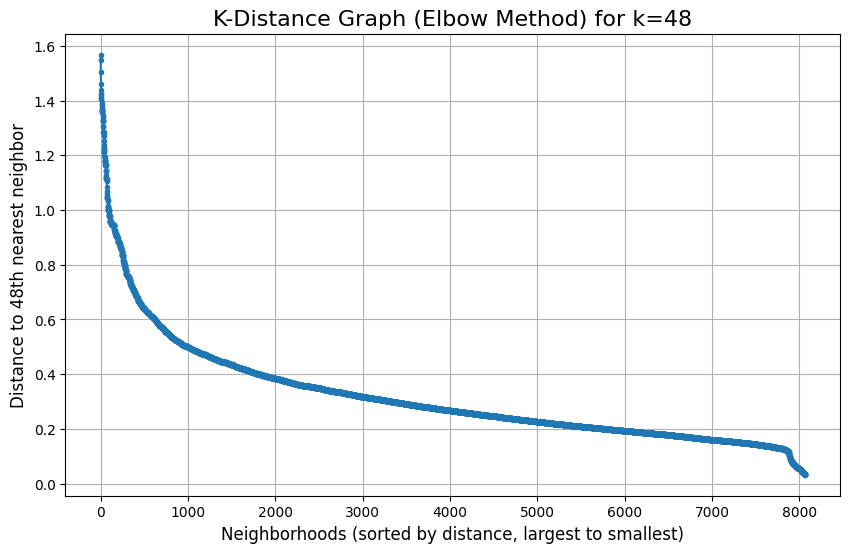

In [6]:
# k is 48 based on the min_samples we chose
k = 48
X_features = norm_df.drop("Street_Name", axis=1).values

# Fit the algorithm on our data
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_features)

# Calculate distances
distances, indices = neighbors_fit.kneighbors(X_features)

# Extract the distance to the 48th neighbor ( most distant neighbor of the 48 )
k_distances = distances[:, k-1]

# FLIP THE GRAPH: Sort the distances in descending order using [::-1]
k_distances_sorted_desc = np.sort(k_distances)[::-1]

# Lot the flipped K-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted_desc, marker='.', linestyle='solid')
plt.title(f'K-Distance Graph (Elbow Method) for k={k}', fontsize=16)
plt.xlabel('Neighborhoods (sorted by distance, largest to smallest)', fontsize=12)
plt.ylabel('Distance to 48th nearest neighbor', fontsize=12)
plt.grid(True)
plt.show()

We can see that between the elbow is between 0.4~0.5

Let's run a for loop on this range of eps values to see which one gets us the better resoults.

In [7]:
# Let's test eps values from 0.2 up to 0.8 in increments of 0.05
for eps_value in np.arange(0.2, 0.8, 0.05):
    
    # Run DBSCAN with the current eps and our locked-in min_samples of 48
    db = DBSCAN(eps=eps_value, min_samples = 48).fit(norm_df.drop("Street_Name", axis=1))
    labels = db.labels_
    
    # Calculate clusters and noise
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    # Only print results if it found more than 1 cluster
    if n_clusters_ > 1:
        print(f"eps={eps_value:.2f} | Clusters: {n_clusters_} | Noise Points: {n_noise_} -> {(n_noise_/8070)*100:.2f} %") # 245 is the amount of samples

eps=0.20 | Clusters: 3 | Noise Points: 4203 -> 52.08 %
eps=0.25 | Clusters: 3 | Noise Points: 2912 -> 36.08 %
eps=0.30 | Clusters: 3 | Noise Points: 1939 -> 24.03 %
eps=0.35 | Clusters: 4 | Noise Points: 1234 -> 15.29 %
eps=0.40 | Clusters: 2 | Noise Points: 778 -> 9.64 %


We can see that the first optimal eps values for which we get a low amount of noise is for eps=3.5 with 4 clusters.

Let's choose those hyperparameters.

In [8]:
# Running DBSCAN on the parameters we found
db_final = DBSCAN(eps=0.4, min_samples = 48).fit(norm_df.drop("Street_Name",axis = 1))
labels = db_final.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Attaching the cluster lablels to the data pre pca and normalization
pre_norm_df_final["Cluster"] = labels

print("Number of clusters: %d" % n_clusters_)
print("Number of noise points: %d" % n_noise_)

Number of clusters: 2
Number of noise points: 778


# Showing the clusters on the map

In [9]:
output(labels)

The labels: 0       0
1       0
2       0
3       0
4       0
       ..
8064    0
8065    0
8066    0
8067    0
8068    0
Length: 8069, dtype: int64
Value Counts:
  0    7222
-1     778
 1      69
Name: count, dtype: int64


Problematic result, but why? Because of the dimension of our data. We also tried NMF but still got bad results, other clustering algos work better...